In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

df_recipes = pd.read_csv('../data/raw/RAW_recipes.csv')     # Đọc file dữ liệu món ăn từ thư mục raw
df_interactions = pd.read_csv('../data/raw/RAW_interactions.csv')

print(f"Recipes: {df_recipes.shape[0]} dòng x {df_recipes.shape[1]} cột")
print(f"Interactions: {df_interactions.shape[0]} dòng x {df_interactions.shape[1]} cột")

Recipes: 231637 dòng x 12 cột
Interactions: 1132367 dòng x 5 cột


In [20]:
display(df_recipes.columns)
display(df_interactions.columns)

display(df_recipes.head(1))                                # Hiển thị món
display(df_interactions.head(1))                           # Hiển thị review

# Kiểu DL từng cột
df_recipes.dtypes
df_interactions.dtypes

# Kiểm tra các kiểu dữ liệu
df_recipes.info()
df_interactions.info()

#Thống kê dữ liệu
df_recipes.describe()
df_interactions.describe()

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='str')

Index(['user_id', 'recipe_id', 'date', 'rating', 'review'], dtype='str')

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course', 'main-i...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'depending on ...",autumn is my favorite time of year to cook! this recipe ...,"['winter squash', 'mexican seasoning', 'mixed spice', 'h...",7


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for 15 minute...


<class 'pandas.DataFrame'>
RangeIndex: 231637 entries, 0 to 231636
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   name            231636 non-null  str  
 1   id              231637 non-null  int64
 2   minutes         231637 non-null  int64
 3   contributor_id  231637 non-null  int64
 4   submitted       231637 non-null  str  
 5   tags            231637 non-null  str  
 6   nutrition       231637 non-null  str  
 7   n_steps         231637 non-null  int64
 8   steps           231637 non-null  str  
 9   description     226658 non-null  str  
 10  ingredients     231637 non-null  str  
 11  n_ingredients   231637 non-null  int64
dtypes: int64(5), str(7)
memory usage: 21.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1132367 non-null  int64
 1   recipe_id  

,user_id,recipe_id,rating
count,1132367.00,1132367.00,1132367.00
mean,138429067.43,160897.21,4.41
std,501426863.68,130398.72,1.26
min,1533.00,38.00,0.00
25%,135470.00,54257.00,4.00
50%,330937.00,120547.00,5.00
75%,804550.00,243852.00,5.00
max,2002372706.00,537716.00,5.00


In [21]:
df_recipes.isnull().sum()                                   # Kiểm tra dữ liệu bị null
#df['calories'].fillna(df['calories'].mean(), inplace=True)

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [22]:
df_recipes.duplicated().sum()                           # Kiểm tra dữ liệu trùng

np.int64(0)

In [27]:
df_recipes['num_ingredients'] = df_recipes['ingredients'].apply(len)        #Đếm số nguyên liệu mỗi món
df_recipes['ingredient_list'] = df_recipes['ingredients'].apply(lambda x: x.split(','))


print(df_recipes['num_ingredients'])
#print(df_recipes.iloc[7])



0          93
1          86
2         193
3         186
4         110
         ... 
231632    345
231633    205
231634    146
231635    162
231636    104
Name: num_ingredients, Length: 231637, dtype: int64


In [28]:
from collections import Counter

all_ingredients = []

for i in df_recipes['ingredient_list']:
    all_ingredients.extend(i)

Counter(all_ingredients).most_common(10)                    # Tìm nguyên liệu phổ biến nhất

[(" 'salt'", 78127),
 (" 'butter'", 38862),
 (" 'sugar'", 38756),
 (" 'onion'", 35739),
 (" 'eggs'", 28726),
 (" 'water'", 27119),
 (" 'garlic cloves'", 24459),
 (" 'olive oil'", 23934),
 (" 'milk'", 21359),
 (" 'flour'", 19695)]

In [29]:
# Join rating vào df_recipes
# df_recipes = df_recipes.merge(df_interactions[['recipe_id','rating']], left_on = 'id', right_on = 'recipe_id', how='left')
# df_recipes.head(2)

#Convert Nutrition
# Calories  -  TotalFat  -  Sugar  -  Sodium  -  Protein  -  SaturatedFat  -  Carbohydrates

# df_recipes['nutrition'] = df_recipes['nutrition'].apply(ast.literal_eval)
# df_recipes['calories'] = df_recipes['nutrition'].apply(lambda x : x[0])
# df_recipes['fat'] = df_recipes['nutrition'].apply(lambda x : x[1])
# df_recipes['sugar'] = df_recipes['nutrition'].apply(lambda x : x[2])
# df_recipes['sodium'] = df_recipes['nutrition'].apply(lambda x : x[3])
# df_recipes['protein'] = df_recipes['nutrition'].apply(lambda x : x[4])
# df_recipes['sat_fat'] = df_recipes['nutrition'].apply(lambda x : x[5])
# df_recipes['carbs'] = df_recipes['nutrition'].apply(lambda x : x[6])

nutrition_cols = [
    "calories",
    "fat",
    "sugar",
    "sodium",
    "protein",
    "saturated_fat",
    "carbs"
]

df_recipes[nutrition_cols] = pd.DataFrame(
    df_recipes['nutrition'].apply(ast.literal_eval).tolist(),
    index=df_recipes.index
)

df_recipes[nutrition_cols].describe()


,calories,fat,sugar,sodium,protein,saturated_fat,carbs
count,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00
mean,473.94,36.08,84.30,30.15,34.68,45.59,15.56
std,1189.71,77.80,800.08,131.96,58.47,98.24,81.82
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,174.40,8.00,9.00,5.00,7.00,7.00,4.00
50%,313.40,20.00,25.00,14.00,18.00,23.00,9.00
75%,519.70,41.00,68.00,33.00,51.00,52.00,16.00
max,434360.20,17183.00,362729.00,29338.00,6552.00,10395.00,36098.00


<Axes: >

<Axes: >

<Axes: >

<Axes: >

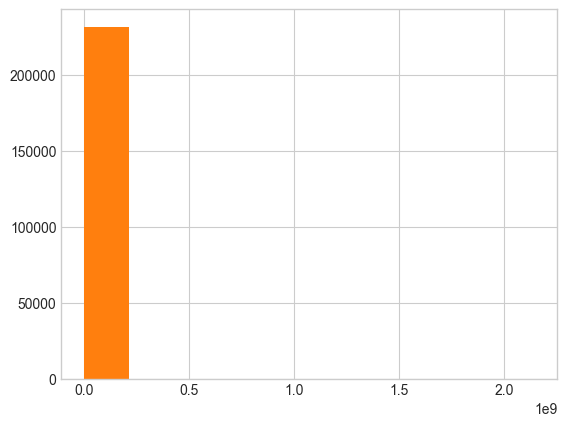

In [31]:
#df_recipes[nutrition_cols].head()
#print(df_recipes[df_recipes['minutes'] > 5000])
#df_recipes.head(1)

display(df_recipes['calories'].hist(bins=50))

display(df_recipes['minutes'].hist())

display(df_recipes['n_ingredients'].hist())

display(df_recipes['protein'].hist())


In [ ]:
# Phân tích độ dài instruction
# Feature Engineering

# viết EDA
# Dataset overview
# Missing value analysis
# Ingredient analysis
# Nutrition analysis
# Rating analysis

# Pipeline EDA

# EDA mở rộng
# Ingredient similarity
# Tag distribution
